<a href="https://colab.research.google.com/github/vitorguisso/fiap-2ano/blob/main/FASE%204/notebooks/CardioIA_Vision_Fase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA Vision – Fase 4

Este notebook apresenta o desenvolvimento do protótipo **CardioIA Vision**, uma solução baseada em **Visão Computacional e Deep Learning** para a classificação automática de imagens de eletrocardiograma (ECG).

O eletrocardiograma é um dos principais exames utilizados para avaliação da atividade elétrica do coração, auxiliando na identificação de diversas condições cardiovasculares. Entretanto, a interpretação dos traçados exige conhecimento especializado e pode demandar tempo dos profissionais de saúde. Nesse contexto, técnicas de Inteligência Artificial podem atuar como ferramentas de apoio ao diagnóstico, contribuindo para a análise automatizada dos exames.

O dataset utilizado neste projeto é composto por imagens de eletrocardiogramas distribuídas em quatro categorias:

* **abnormal_heartbeat_ecg_images:** exames que apresentam alterações no ritmo cardíaco (arritmias e outras anormalidades);
* **myocardial_infarction_ecg_images:** exames associados a casos de infarto do miocárdio;
* **normal_ecg_images:** exames considerados normais, sem alterações significativas identificadas;
* **post_mi_history_ecg_images:** exames de pacientes com histórico prévio de infarto do miocárdio.

A correta identificação dessas categorias possui relevância clínica, uma vez que permite diferenciar exames normais de situações potencialmente associadas a doenças cardiovasculares, auxiliando na priorização de atendimentos e na tomada de decisão médica.

O objetivo deste projeto é investigar a capacidade de diferentes arquiteturas de redes neurais convolucionais em reconhecer padrões visuais presentes nos eletrocardiogramas e classificá-los automaticamente em suas respectivas categorias.

Para isso, foram avaliadas três abordagens distintas:

* Desenvolvimento de uma CNN própria construída do zero;
* Aplicação de Transfer Learning utilizando a arquitetura ResNet50;
* Aplicação de Transfer Learning utilizando a arquitetura VGG16.

O projeto contempla as seguintes etapas:

* Inspeção e compreensão da estrutura do dataset;
* Pré-processamento das imagens;
* Organização dos conjuntos de treino, validação e teste;
* Treinamento dos modelos de Deep Learning;
* Aplicação de técnicas de Transfer Learning;
* Avaliação dos modelos por meio de acurácia, matriz de confusão, precision, recall e F1-score;
* Comparação dos resultados obtidos;
* Seleção da arquitetura com melhor desempenho para o protótipo CardioIA Vision.

Ao final, será realizada uma análise crítica dos resultados obtidos, destacando as vantagens, limitações e oportunidades de evolução da solução proposta.


#ENTREGA PARTE 1 - PRÉ-PROCESSAMENTO

## 1. Montagem do Google Drive

Nesta etapa, o Google Drive é conectado ao ambiente do Colab para permitir o acesso ao dataset, aos arquivos processados e aos modelos salvos durante o projeto.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Inspeção inicial do dataset

Nesta etapa, foi realizada a leitura das pastas do dataset original para verificar se as quatro classes de imagens de ECG foram corretamente carregadas.

O objetivo é confirmar a estrutura dos dados antes de iniciar o pré-processamento.

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_original/ecg_data"

print(os.listdir(BASE_PATH))

['abnormal_heartbeat_ecg_images', 'myocardial_infarction_ecg_images', 'normal_ecg_images', 'post_mi_history_ecg_images']


As quatro classes do dataset foram identificadas corretamente:

- abnormal_heartbeat_ecg_images
- myocardial_infarction_ecg_images
- normal_ecg_images
- post_mi_history_ecg_images

Essa verificação confirma que o dataset foi importado corretamente e está pronto para a etapa de análise exploratória.

### 2.1 Contagem de imagens por classe

Nesta etapa, foi realizada a contagem automática de imagens em cada uma das quatro classes do dataset.

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_original/ecg_data"

classes = {}

for pasta in os.listdir(BASE_PATH):
    caminho = os.path.join(BASE_PATH, pasta)

    if os.path.isdir(caminho):
        quantidade = len([
            arq for arq in os.listdir(caminho)
            if arq.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        classes[pasta] = quantidade

print("RESUMO DO DATASET\n")

total = 0

for classe, qtd in classes.items():
    print(f"{classe}: {qtd} imagens")
    total += qtd

print(f"\nTOTAL DE IMAGENS: {total}")

RESUMO DO DATASET

abnormal_heartbeat_ecg_images: 233 imagens
myocardial_infarction_ecg_images: 239 imagens
normal_ecg_images: 284 imagens
post_mi_history_ecg_images: 172 imagens

TOTAL DE IMAGENS: 928


O dataset possui 928 imagens distribuídas em quatro classes.

A classe com maior quantidade de imagens é `normal_ecg_images`, com 284 imagens. A classe com menor quantidade é `post_mi_history_ecg_images`, com 172 imagens.

Apesar de existir pequeno desbalanceamento entre as classes, o conjunto é adequado para fins acadêmicos e permite a comparação entre CNN própria e modelos de Transfer Learning.

### 2.2 Visualização de exemplos das classes

Nesta etapa foram selecionadas imagens aleatórias de cada uma das quatro categorias do dataset para inspeção visual.

O objetivo foi verificar se os arquivos foram carregados corretamente e compreender as características visuais presentes em cada classe de eletrocardiograma.

A inspeção manual também permite identificar possíveis problemas de qualidade, diferenças de resolução e inconsistências antes do treinamento dos modelos.

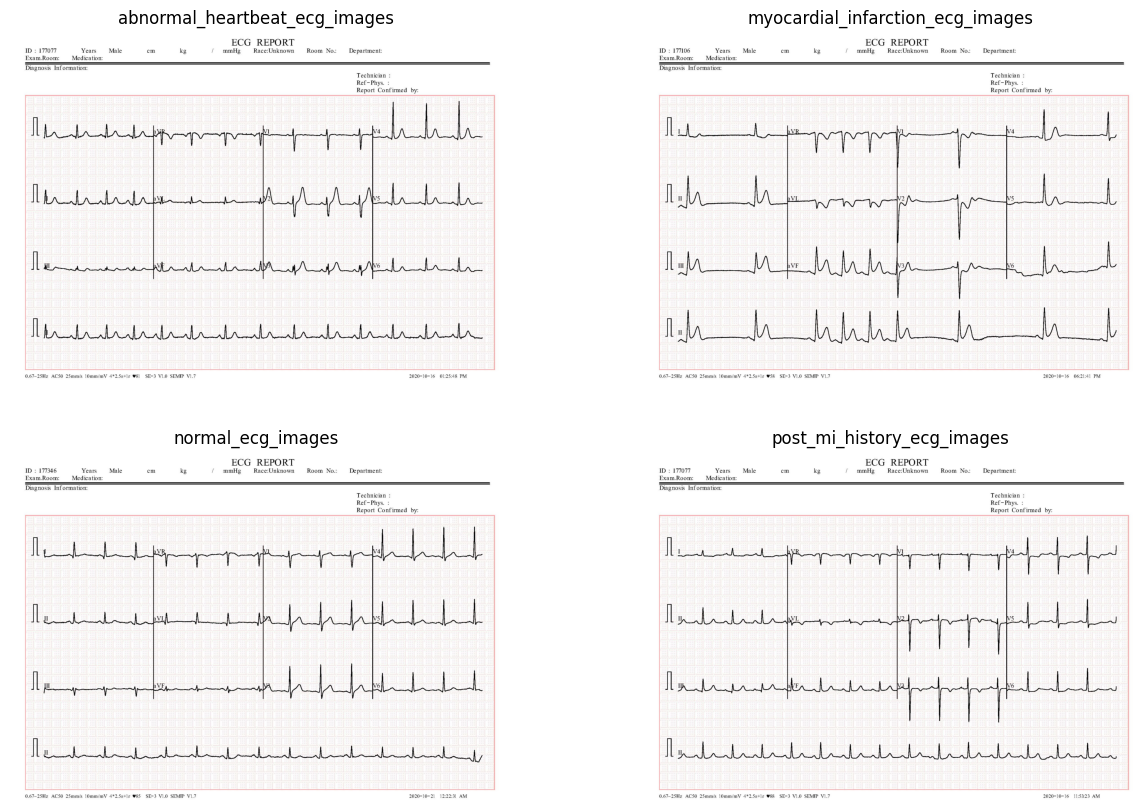

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(15,10))

for i, pasta in enumerate(os.listdir(BASE_PATH)):

    caminho = os.path.join(BASE_PATH, pasta)

    imagens = [
        img for img in os.listdir(caminho)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    imagem_escolhida = random.choice(imagens)

    img = Image.open(
        os.path.join(caminho, imagem_escolhida)
    )

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(pasta)
    plt.axis("off")

plt.show()

### Análise dos resultados

A visualização das amostras confirmou que todas as categorias apresentam imagens de eletrocardiograma com estrutura semelhante, contendo traçados cardíacos distribuídos em múltiplas derivações.

Observa-se elevada similaridade visual entre algumas classes, especialmente entre exames normais e exames relacionados ao histórico de infarto, o que torna o problema de classificação mais desafiador para os modelos de Deep Learning.

Essa característica justifica a utilização de arquiteturas convolucionais e técnicas de Transfer Learning para extração automática de padrões discriminativos.

### 2.3 Análise das características das imagens

Foi realizada uma inspeção automática das propriedades das imagens presentes no dataset.

Para cada arquivo foram extraídas informações como:

Classe de origem;
Largura da imagem;
Altura da imagem;
Modo de cor.

Essas informações auxiliam na identificação de possíveis inconsistências que poderiam impactar o treinamento dos modelos.

In [ ]:
from PIL import Image
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_original/ecg_data"

dados = []

for pasta in os.listdir(BASE_PATH):

    caminho = os.path.join(BASE_PATH, pasta)

    if os.path.isdir(caminho):

        for arquivo in os.listdir(caminho):

            if arquivo.lower().endswith((".jpg",".jpeg",".png")):

                img = Image.open(
                    os.path.join(caminho, arquivo)
                )

                dados.append([
                    pasta,
                    img.size[0],
                    img.size[1],
                    img.mode
                ])

df = pd.DataFrame(
    dados,
    columns=[
        "classe",
        "largura",
        "altura",
        "modo"
    ]
)

df.head()

,classe,largura,altura,modo
0,abnormal_heartbeat_ecg_images,2213,1572,RGB
1,abnormal_heartbeat_ecg_images,2213,1572,RGB
2,abnormal_heartbeat_ecg_images,2213,1572,RGB
3,abnormal_heartbeat_ecg_images,2213,1572,RGB
4,abnormal_heartbeat_ecg_images,2213,1572,RGB


### Resultado da análise das características das imagens

A inspeção automática das imagens permitiu extrair informações referentes à classe de origem, resolução e modo de cor de cada arquivo presente no dataset.

A amostra apresentada demonstra que as imagens pertencem às diferentes categorias do conjunto de dados e possuem características visuais consistentes.

As informações coletadas serão utilizadas para validar a necessidade de etapas de pré-processamento, como redimensionamento e normalização, antes do treinamento dos modelos de Deep Learning.

In [ ]:
print("RESOLUÇÕES ENCONTRADAS:\n")

print(
    df[["largura","altura"]]
    .drop_duplicates()
)

print("\nMODOS DE COR:\n")

print(
    df["modo"]
    .value_counts()
)

RESOLUÇÕES ENCONTRADAS:

   largura  altura
0     2213    1572

MODOS DE COR:

modo
RGB    928
Name: count, dtype: int64


### Resultado da inspeção de resolução e formato de cor

A análise identificou que todas as imagens do dataset possuem resolução padronizada de **2213 x 1572 pixels**.

Também foi verificado que todas as **928 imagens** estão armazenadas no modo de cor **RGB**, não havendo imagens em escala de cinza ou em formatos incompatíveis.

Esses resultados indicam que o conjunto de dados apresenta boa padronização visual, reduzindo a necessidade de tratamentos corretivos adicionais durante o pré-processamento.

A uniformidade observada contribui para maior consistência durante o treinamento dos modelos de classificação, uma vez que todas as imagens seguem o mesmo padrão de entrada.

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
BASE_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_original/ecg_data"

OUTPUT_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado"

os.makedirs(OUTPUT_PATH, exist_ok=True)

classes = os.listdir(BASE_PATH)

for classe in classes:

    caminho_classe = os.path.join(BASE_PATH, classe)

    imagens = [
        img for img in os.listdir(caminho_classe)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_imgs, temp_imgs = train_test_split(
        imagens,
        test_size=0.30,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    for grupo, lista in {
        "train": train_imgs,
        "validation": val_imgs,
        "test": test_imgs
    }.items():

        pasta_destino = os.path.join(
            OUTPUT_PATH,
            grupo,
            classe
        )

        os.makedirs(
            pasta_destino,
            exist_ok=True
        )

        for img in lista:

            origem = os.path.join(
                caminho_classe,
                img
            )

            destino = os.path.join(
                pasta_destino,
                img
            )

            shutil.copy2(
                origem,
                destino
            )

print("Dataset dividido com sucesso!")

Dataset dividido com sucesso!


### Resultado da divisão do dataset

A divisão do conjunto de dados foi concluída com sucesso.

As imagens foram organizadas automaticamente em três subconjuntos independentes:

- Treinamento (Train)
- Validação (Validation)
- Teste (Test)

A estrutura criada será utilizada nas próximas etapas do projeto para treinamento, ajuste de hiperparâmetros e avaliação dos modelos de classificação.

Essa separação garante que os dados utilizados para avaliação final não sejam vistos durante o processo de treinamento, permitindo uma análise mais confiável da capacidade de generalização dos modelos.

In [ ]:
for grupo in ["train", "validation", "test"]:

    print(f"\n{grupo.upper()}")

    caminho_grupo = os.path.join(
        OUTPUT_PATH,
        grupo
    )

    total = 0

    for classe in os.listdir(caminho_grupo):

        qtd = len(
            os.listdir(
                os.path.join(
                    caminho_grupo,
                    classe
                )
            )
        )

        total += qtd

        print(
            f"{classe}: {qtd}"
        )

    print(
        f"TOTAL: {total}"
    )


TRAIN
abnormal_heartbeat_ecg_images: 163
myocardial_infarction_ecg_images: 167
normal_ecg_images: 198
post_mi_history_ecg_images: 120
TOTAL: 648

VALIDATION
abnormal_heartbeat_ecg_images: 35
myocardial_infarction_ecg_images: 36
normal_ecg_images: 43
post_mi_history_ecg_images: 26
TOTAL: 140

TEST
abnormal_heartbeat_ecg_images: 35
myocardial_infarction_ecg_images: 36
normal_ecg_images: 43
post_mi_history_ecg_images: 26
TOTAL: 140


### Resultado da distribuição das imagens

Após a divisão do dataset, foi realizada uma verificação automática da quantidade de imagens presentes em cada subconjunto.

#### Conjunto de Treinamento

| Classe | Imagens |
|----------|----------:|
| Abnormal Heartbeat | 163 |
| Myocardial Infarction | 167 |
| Normal ECG | 198 |
| Post Myocardial Infarction History | 120 |
| **Total** | **648** |

#### Conjunto de Validação

| Classe | Imagens |
|----------|----------:|
| Abnormal Heartbeat | 35 |
| Myocardial Infarction | 36 |
| Normal ECG | 43 |
| Post Myocardial Infarction History | 26 |
| **Total** | **140** |

#### Conjunto de Teste

| Classe | Imagens |
|----------|----------:|
| Abnormal Heartbeat | 35 |
| Myocardial Infarction | 36 |
| Normal ECG | 43 |
| Post Myocardial Infarction History | 26 |
| **Total** | **140** |

Os resultados confirmam que a divisão foi realizada corretamente, preservando a proporção original das classes em todos os subconjuntos.

A maior parte das imagens foi destinada ao treinamento (70%), enquanto os conjuntos de validação e teste receberam aproximadamente 15% cada.

Essa estratégia permite treinar os modelos com quantidade suficiente de exemplos, ao mesmo tempo em que garante conjuntos independentes para ajuste e avaliação final do desempenho.

# 3. Preparação para o treinamento dos modelos de Deep Learning

Nesta etapa inicia-se a construção dos modelos de Visão Computacional responsáveis pela classificação automática das imagens de eletrocardiograma.

O objetivo é preparar os dados para o treinamento de diferentes arquiteturas de Redes Neurais Convolucionais (CNNs), permitindo comparar o desempenho de uma CNN desenvolvida do zero com modelos baseados em Transfer Learning.

Serão utilizados geradores de imagens do TensorFlow para realizar automaticamente o carregamento, pré-processamento e fornecimento dos dados aos modelos durante o treinamento.

As principais etapas desta fase incluem:

Configuração do ambiente TensorFlow;
Definição dos diretórios de treinamento, validação e teste;
Redimensionamento automático das imagens para 224 × 224 pixels;
Normalização dos valores dos pixels para o intervalo entre 0 e 1;
Aplicação de técnicas de Data Augmentation no conjunto de treinamento;
Preparação dos geradores de dados para alimentar as redes neurais.

Essa abordagem reduz o consumo de memória, aumenta a capacidade de generalização dos modelos e torna o processo de treinamento mais eficiente.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### 3.1 Importação das bibliotecas de Deep Learning

Nesta etapa são importadas as bibliotecas necessárias para a construção e treinamento das redes neurais.

O TensorFlow será utilizado como framework principal de Deep Learning, enquanto o ImageDataGenerator será responsável pelo carregamento e pré-processamento das imagens durante o treinamento.

Essas ferramentas permitem implementar tanto a CNN própria quanto os modelos de Transfer Learning avaliados posteriormente.

In [ ]:
IMG_SIZE = (224, 224)

TRAIN_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/train"
VAL_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/validation"
TEST_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/test"

### 3.2 Definição dos parâmetros de entrada

Nesta etapa são definidos os caminhos dos conjuntos de treinamento, validação e teste criados durante o pré-processamento.

Também é especificado o tamanho das imagens de entrada (224 × 224 pixels), compatível com arquiteturas modernas de Deep Learning como VGG16 e ResNet50.

A padronização das dimensões garante que todas as imagens possam ser processadas de forma uniforme pelos modelos.

### 3.3 Configuração dos geradores de dados e Data Augmentation

Nesta etapa são configurados os geradores responsáveis pelo carregamento das imagens durante o treinamento dos modelos.

Além da normalização dos pixels para o intervalo entre 0 e 1, foram aplicadas técnicas de Data Augmentation no conjunto de treinamento, incluindo:

- Rotação de até 10 graus;
- Zoom de até 10%;
- Deslocamentos horizontais;
- Deslocamentos verticais.

Essas transformações geram pequenas variações nas imagens originais, aumentando a diversidade dos exemplos apresentados à rede neural e reduzindo o risco de overfitting.

Para os conjuntos de validação e teste foi aplicada apenas a normalização dos pixels, preservando as imagens originais para avaliação imparcial dos modelos.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=False
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

### 3.4 Criação dos geradores de treinamento, validação e teste

Após a configuração dos geradores, foram criados os fluxos de carregamento das imagens para os conjuntos de treinamento, validação e teste.

As imagens são carregadas automaticamente dos diretórios previamente organizados durante o pré-processamento.

Os principais parâmetros utilizados foram:

- Dimensão das imagens: 224 × 224 pixels;
- Tamanho do lote (batch size): 32 imagens;
- Classificação multiclasse utilizando codificação categórica (categorical).

Essa estrutura permite alimentar os modelos de Deep Learning de forma eficiente durante todo o processo de treinamento e avaliação.

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

### 3.5 Verificação das classes identificadas

Nesta etapa foi realizada a conferência automática das classes encontradas pelo TensorFlow.

O objetivo é garantir que as categorias do dataset foram corretamente reconhecidas e associadas aos respectivos rótulos utilizados durante o treinamento.

Essa verificação evita inconsistências entre os dados de entrada e as saídas previstas pelos modelos.

In [ ]:
print("Classes encontradas:")

print(train_generator.class_indices)

### Resultado da identificação das classes

O TensorFlow identificou corretamente as quatro categorias presentes no dataset e realizou o mapeamento automático dos rótulos utilizados durante o treinamento.

Esse mapeamento será utilizado pelos modelos para associar cada imagem à sua respectiva condição clínica durante o processo de classificação.

A correta identificação das classes garante consistência entre os dados de entrada e as previsões produzidas pelas redes neurais.

# ENTREGA PARTE 2 - CLASSIFICAÇÃO DE IMAGENS

# 4. Implementação da CNN Própria

Como primeira abordagem, foi desenvolvida uma Rede Neural Convolucional (CNN) do zero.

O objetivo desta arquitetura é servir como modelo de referência para comparação posterior com técnicas de Transfer Learning.

A rede foi construída utilizando múltiplas camadas convolucionais e de agrupamento (MaxPooling), responsáveis pela extração automática de características relevantes das imagens de eletrocardiograma.

Ao final da arquitetura, foram utilizadas camadas densas para realizar a classificação das quatro categorias presentes no dataset.

### 4.1 Arquitetura da CNN

A arquitetura desenvolvida possui:

- Três blocos convolucionais;
- Camadas MaxPooling para redução dimensional;
- Camada Flatten para conversão dos mapas de características em vetor;
- Camada densa com 128 neurônios;
- Dropout de 50% para reduzir overfitting;
- Camada de saída Softmax com quatro classes.

O treinamento foi configurado utilizando:

- Otimizador Adam;
- Função de perda Categorical Crossentropy;
- Métrica principal: Accuracy.

In [ ]:
from tensorflow.keras import layers, models

num_classes = 4

cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

### Resultado da arquitetura da CNN

A arquitetura criada possui três blocos convolucionais responsáveis pela extração de características visuais presentes nos eletrocardiogramas.

As camadas convolucionais aumentam progressivamente a quantidade de filtros (32, 64 e 128), permitindo que a rede aprenda padrões cada vez mais complexos.

Ao final da rede foi utilizada uma camada densa com Dropout de 50%, reduzindo o risco de overfitting durante o treinamento.

A camada de saída utiliza a função Softmax para realizar a classificação das quatro categorias presentes no dataset.

### 4.2 Treinamento da CNN

A CNN foi treinada utilizando o conjunto de treinamento previamente preparado.

Durante o processo, o modelo recebeu imagens aumentadas artificialmente pelo Data Augmentation e teve seu desempenho monitorado através do conjunto de validação.

Foram executadas 15 épocas de treinamento, permitindo acompanhar a evolução da capacidade de aprendizagem da rede neural.

In [ ]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

### Resultado do treinamento da CNN

O treinamento foi executado durante 15 épocas utilizando imagens previamente normalizadas e ampliadas por Data Augmentation.

Ao longo das épocas, foram monitoradas as métricas de acurácia e perda tanto para o conjunto de treinamento quanto para o conjunto de validação.

Os resultados obtidos permitiram avaliar a capacidade de aprendizagem e generalização da arquitetura proposta.

### 4.3 Evolução do treinamento

Após o treinamento, foram gerados gráficos de acurácia e perda (loss) para análise do comportamento da rede neural ao longo das épocas.

Esses gráficos permitem identificar:

- Evolução do aprendizado;
- Capacidade de generalização;
- Possíveis sinais de overfitting ou underfitting.

A interpretação dos resultados será realizada após a execução dos gráficos.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_cnn.history['accuracy'], label='Treino')
plt.plot(history_cnn.history['val_accuracy'], label='Validação')

plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)

plt.plot(history_cnn.history['loss'], label='Treino')
plt.plot(history_cnn.history['val_loss'], label='Validação')

plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Análise dos gráficos de treinamento

Os gráficos apresentam a evolução da acurácia e da função de perda (loss) ao longo das 15 épocas de treinamento da CNN.

Observa-se que a acurácia permaneceu próxima de 30% tanto para treinamento quanto para validação, indicando que o modelo apresentou capacidade limitada de aprendizado das características presentes nas imagens de ECG.

A função de perda apresentou redução inicial nas primeiras épocas, porém rapidamente se estabilizou, sugerindo que a rede atingiu um limite de aprendizado sem conseguir melhorar significativamente seu desempenho.

Não foram observados indícios de overfitting, uma vez que as curvas de treinamento e validação permaneceram próximas durante todo o processo.

Os resultados sugerem a ocorrência de underfitting, situação em que a arquitetura utilizada não possui capacidade suficiente para extrair padrões complexos do conjunto de dados.

Esse comportamento reforça a importância da próxima etapa do projeto, na qual serão utilizados modelos de Transfer Learning, como ResNet50 e VGG16, capazes de aproveitar conhecimentos previamente aprendidos em grandes bases de imagens.

### 4.4 Salvamento do modelo

Após o treinamento, o modelo foi salvo em formato .keras para possibilitar reutilização futura sem necessidade de novo treinamento.

Essa etapa permite carregar a rede treinada posteriormente para testes, avaliações e integração ao protótipo CardioIA Vision.

In [ ]:
cnn_model.save(
    "/content/drive/MyDrive/CardioIA_Vision/cnn_model_fase4.keras"
)

# 5.Transfer Learning com ResNet50

### 5.1 Introdução ao modelo ResNet50
Como segunda abordagem do projeto, foi utilizado o modelo ResNet50 através da técnica de Transfer Learning.

A ResNet50 (Residual Network) é uma arquitetura profunda de Redes Neurais Convolucionais desenvolvida pela Microsoft Research e vencedora da competição ImageNet em 2015.

Seu principal diferencial é a utilização de conexões residuais (Residual Connections), que permitem o treinamento de redes muito mais profundas sem sofrer significativamente com o problema do desaparecimento do gradiente (Vanishing Gradient).

O modelo foi originalmente treinado em milhões de imagens do banco ImageNet, sendo capaz de reconhecer padrões visuais complexos. Por meio do Transfer Learning, esse conhecimento prévio pode ser aproveitado em tarefas específicas, como a classificação de eletrocardiogramas.

A utilização da ResNet50 busca aumentar a capacidade de extração de características quando comparada à CNN construída do zero, especialmente em cenários com quantidade limitada de imagens disponíveis para treinamento.

### 5.2 Configuração do ambiente e preparação dos dados
Nesta etapa foi realizada a configuração do ambiente de treinamento utilizando a biblioteca TensorFlow.

Inicialmente foi verificada a disponibilidade de processamento por GPU, recurso importante para acelerar o treinamento dos modelos de Deep Learning.

Também foram definidos os caminhos dos conjuntos de treinamento, validação e teste gerados durante a etapa de pré-processamento.

Para aumentar a capacidade de generalização do modelo foi utilizado o recurso de Data Augmentation por meio da classe ImageDataGenerator. Foram aplicadas pequenas transformações geométricas, incluindo rotações, zoom e deslocamentos horizontais e verticais.

Além disso, todas as imagens tiveram seus valores de pixel normalizados para o intervalo entre 0 e 1 através da divisão por 255, garantindo maior estabilidade durante o treinamento da rede neural.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("GPU disponível:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = (224, 224)

TRAIN_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/train"
VAL_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/validation"
TEST_PATH = "/content/drive/MyDrive/CardioIA_Vision/dataset_processado/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=False
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

GPU disponível: []
Found 648 images belonging to 4 classes.
Found 140 images belonging to 4 classes.
Found 140 images belonging to 4 classes.
{'abnormal_heartbeat_ecg_images': 0, 'myocardial_infarction_ecg_images': 1, 'normal_ecg_images': 2, 'post_mi_history_ecg_images': 3}


Após a configuração dos geradores de imagens, foram criados os fluxos de dados utilizados durante o treinamento do modelo.

As imagens foram carregadas automaticamente a partir das pastas organizadas na etapa anterior, sendo redimensionadas para 224 × 224 pixels e agrupadas em lotes de 32 imagens.

Foi utilizada a classificação categórica (categorical), adequada para problemas multiclasse, permitindo que o modelo identificasse uma das quatro categorias de eletrocardiogramas presentes no dataset.

O conjunto de teste foi configurado sem embaralhamento (shuffle=False), garantindo a preservação da ordem das imagens para futuras avaliações e geração de métricas de desempenho.

### 5.3 Verificação das classes identificadas

Após a criação dos geradores de treinamento, validação e teste, foi realizada a conferência automática das classes reconhecidas pelo TensorFlow.

O objetivo dessa verificação é garantir que as categorias presentes no dataset foram corretamente identificadas e associadas aos respectivos rótulos utilizados durante o treinamento.

Os resultados demonstraram que os três subconjuntos foram carregados corretamente:

- Treinamento: 648 imagens
- Validação: 140 imagens
- Teste: 140 imagens

Também foi confirmada a existência das quatro classes utilizadas no projeto:

- abnormal_heartbeat_ecg_images
- myocardial_infarction_ecg_images
- normal_ecg_images
- post_mi_history_ecg_images

O TensorFlow realizou automaticamente o seguinte mapeamento dos rótulos:

| Classe | Índice |
|----------|----------|
| abnormal_heartbeat_ecg_images | 0 |
| myocardial_infarction_ecg_images | 1 |
| normal_ecg_images | 2 |
| post_mi_history_ecg_images | 3 |

Esses índices serão utilizados internamente pelos modelos durante o processo de treinamento e classificação das imagens.

Os resultados confirmam que os dados foram carregados corretamente e estão prontos para utilização na etapa de Transfer Learning com a ResNet50.

### 5.4 Configuração da arquitetura ResNet50

Nesta etapa foi realizada a configuração do modelo ResNet50 utilizando a técnica de Transfer Learning.

A ResNet50 foi carregada com pesos pré-treinados da base ImageNet, permitindo aproveitar conhecimentos adquiridos previamente durante o treinamento em milhões de imagens.

Foi utilizada a configuração `include_top=False`, removendo a camada de classificação original do modelo para que uma nova estrutura pudesse ser adaptada ao problema de classificação dos eletrocardiogramas.

As imagens de entrada foram definidas com dimensão de 224 × 224 pixels e três canais de cor (RGB), mantendo compatibilidade com a arquitetura original da ResNet50.

Além disso, as camadas do modelo pré-treinado foram inicialmente congeladas (`trainable=False`), permitindo que a rede atuasse apenas como extratora de características visuais.

Essa estratégia reduz o tempo de treinamento, diminui o risco de overfitting e costuma produzir melhores resultados quando comparada ao treinamento completo de uma rede neural a partir do zero, especialmente em conjuntos de dados com quantidade limitada de imagens.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 5.5 Construção da arquitetura de classificação da ResNet50

Após o carregamento da ResNet50 pré-treinada, foi construída uma nova arquitetura de classificação adaptada ao problema deste projeto.

A ResNet50 foi utilizada como base para extração de características visuais das imagens de eletrocardiograma. Em seguida, foram adicionadas novas camadas responsáveis por transformar essas características em uma classificação final.

A arquitetura adicionada contém:

- Uma camada `GlobalAveragePooling2D`, responsável por reduzir os mapas de características gerados pela ResNet50;
- Uma camada densa com 128 neurônios e função de ativação ReLU;
- Uma camada `Dropout` com taxa de 50%, utilizada para reduzir o risco de overfitting;
- Uma camada final `Dense` com função Softmax, responsável por classificar as imagens em uma das quatro categorias do dataset.

O modelo foi compilado utilizando o otimizador Adam, a função de perda `categorical_crossentropy` e a métrica de acurácia.

In [ ]:
resnet_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        4,
        activation='softmax'
    )

])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Resultado da arquitetura da ResNet50

A arquitetura final foi construída com sucesso utilizando a ResNet50 como extratora de características visuais.

A saída da ResNet50 possui dimensão (7 × 7 × 2048), representando mapas de características extraídos das imagens de eletrocardiograma após o processamento pelas diversas camadas convolucionais da rede.

Em seguida, foi aplicada uma camada GlobalAveragePooling2D, responsável por reduzir a dimensionalidade dos dados e transformar os mapas de características em um vetor de 2048 atributos. Essa abordagem reduz significativamente a quantidade de parâmetros quando comparada ao uso de camadas totalmente conectadas tradicionais.

Sobre essa representação foram adicionadas:

- Uma camada densa com 128 neurônios e função de ativação ReLU;
- Uma camada Dropout de 50% para reduzir o risco de overfitting;
- Uma camada de saída com 4 neurônios e função Softmax, correspondente às quatro categorias do dataset.

Os resultados do resumo do modelo demonstraram:

| Métrica | Valor |
|----------|----------|
| Parâmetros totais | 23.850.500 |
| Parâmetros treináveis | 262.788 |
| Parâmetros não treináveis | 23.587.712 |

Observa-se que mais de 23 milhões de parâmetros permaneceram congelados durante o treinamento. Dessa forma, apenas a camada classificadora adicionada ao projeto foi treinada, reduzindo o custo computacional e aproveitando o conhecimento previamente adquirido pela ResNet50 durante seu treinamento na base ImageNet.

Essa estratégia é uma das principais vantagens do Transfer Learning, permitindo obter bons resultados mesmo em conjuntos de dados relativamente pequenos, como o utilizado neste projeto.

### 5.6 Treinamento inicial da ResNet50

Nesta etapa foi realizado o primeiro treinamento do modelo ResNet50 utilizando as camadas convolucionais da rede pré-treinada congeladas.

Nesse primeiro momento, apenas as camadas classificadoras adicionadas ao final da arquitetura foram treinadas, enquanto os pesos originais da ResNet50 permaneceram fixos.

O treinamento foi executado durante 10 épocas, utilizando o conjunto de treinamento para ajuste dos pesos e o conjunto de validação para monitoramento do desempenho.

Essa etapa teve como objetivo avaliar o desempenho inicial da ResNet50 como extratora de características visuais para classificação das imagens de ECG.

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 218s 10s/step - accuracy: 0.2963 - loss: 1.4939 - val_accuracy: 0.3214 - val_loss: 1.3683
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2793 - loss: 1.3959 - val_accuracy: 0.3071 - val_loss: 1.3607
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2978 - loss: 1.3767 - val_accuracy: 0.3143 - val_loss: 1.3615
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3148 - loss: 1.3809 - val_accuracy: 0.4071 - val_loss: 1.3649
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2994 - loss: 1.3780 - val_accuracy: 0.3429 - val_loss: 1.3676
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3241 - loss: 1.3761 - val_accuracy: 0.3357 - val_loss: 1.3647
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3148 - loss: 1.3719 - val_accuracy: 0.3714 - val_loss: 1.3624
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2994 - loss: 1.3737 - val_accuracy: 0.3714 - val_los

### Resultado do treinamento inicial da ResNet50

O treinamento inicial da ResNet50 apresentou desempenho superior ao da CNN própria, porém ainda limitado para o problema de classificação das quatro classes de ECG.

A acurácia de treinamento variou ao longo das épocas, encerrando em aproximadamente 32,25%, enquanto a acurácia de validação final ficou em aproximadamente 34,29%.

A função de perda apresentou redução moderada, mas permaneceu em valores próximos de 1,36 no conjunto de validação, indicando que o modelo ainda apresentava dificuldade em separar adequadamente as classes.

Esse resultado sugeriu que utilizar a ResNet50 apenas como extratora de características congelada não foi suficiente para alcançar desempenho satisfatório, motivando a aplicação de Fine Tuning nas camadas finais da rede.

### 5.7 Aplicação de Fine Tuning na ResNet50

Após o treinamento inicial, foi aplicada a técnica de Fine Tuning para permitir uma adaptação mais profunda da ResNet50 ao conjunto de imagens de eletrocardiograma.

Nessa etapa, parte das camadas finais da ResNet50 foi descongelada, permitindo que seus pesos fossem ajustados durante um novo treinamento.

As camadas iniciais permaneceram congeladas, pois geralmente capturam características visuais mais genéricas, como bordas, linhas e texturas. Já as camadas finais tendem a representar padrões mais específicos, sendo mais adequadas para adaptação ao novo domínio.

Para evitar alterações bruscas nos pesos pré-treinados, foi utilizado o otimizador Adam com taxa de aprendizado reduzida (`learning_rate=1e-5`).

Essa estratégia busca melhorar o desempenho do modelo sem perder completamente o conhecimento previamente adquirido durante o treinamento na base ImageNet.

In [ ]:
from tensorflow.keras.optimizers import Adam

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 14,712,964 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

### Resultado da configuração do Fine Tuning

Após o descongelamento parcial da ResNet50, o modelo passou a apresentar uma quantidade maior de parâmetros treináveis.

O resumo da arquitetura demonstrou:

- 23.850.500 parâmetros totais;
- 14.712.964 parâmetros treináveis;
- 9.137.536 parâmetros não treináveis.

Esse resultado confirma que parte significativa das camadas finais da ResNet50 foi liberada para treinamento, permitindo que o modelo ajustasse representações mais específicas ao conjunto de imagens de ECG.

Dessa forma, o Fine Tuning tornou o modelo mais flexível do que a versão inicial totalmente congelada, possibilitando maior adaptação ao problema proposto.

### 5.8 Treinamento da ResNet50 com Fine Tuning

Com as camadas finais da ResNet50 descongeladas, foi realizado um novo treinamento do modelo.

Essa etapa teve como objetivo refinar os pesos das camadas mais profundas da rede, permitindo maior adaptação aos padrões visuais presentes nas imagens de eletrocardiograma.

O treinamento foi executado por 10 épocas, mantendo o uso dos conjuntos de treinamento e validação previamente definidos.

A expectativa desta etapa era melhorar a capacidade de classificação do modelo em relação ao treinamento inicial com a ResNet50 congelada.

In [ ]:
history_finetune = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.3071 - loss: 1.4176 - val_accuracy: 0.2500 - val_loss: 1.3635
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3904 - loss: 1.3001 - val_accuracy: 0.2500 - val_loss: 1.3675
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4398 - loss: 1.2740 - val_accuracy: 0.2500 - val_loss: 1.3817
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4306 - loss: 1.2630 - val_accuracy: 0.2500 - val_loss: 1.4057
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5062 - loss: 1.2038 - val_accuracy: 0.2500 - val_loss: 1.4508
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4769 - loss: 1.2273 - val_accuracy: 0.2500 - val_loss: 1.4621
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5262 - loss: 1.1544 - val_accuracy: 0.2500 - val_loss: 1.4314
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5077 - loss: 1.1469 - val_accuracy: 0.2500 - val_loss:

### Resultado do treinamento com Fine Tuning

O treinamento com Fine Tuning apresentou aumento expressivo da acurácia no conjunto de treinamento, que chegou a aproximadamente 54,94% na última época.

Entretanto, a acurácia de validação permaneceu baixa, encerrando em aproximadamente 26,43%.

Esse comportamento indica que o modelo passou a aprender melhor os dados de treinamento, mas não conseguiu generalizar adequadamente para o conjunto de validação.

A diferença entre a acurácia de treinamento e validação sugere a ocorrência de overfitting, ou seja, o modelo se ajustou aos padrões do conjunto de treino, mas teve dificuldade para aplicar esse aprendizado em imagens não vistas.

Observa-se ainda que a função de perda de validação permaneceu relativamente elevada ao longo do treinamento, encerrando em aproximadamente 1,30. Esse comportamento reforça a evidência de dificuldade de generalização do modelo para imagens não vistas.

Apesar disso, o Fine Tuning foi uma etapa importante para avaliar os limites da ResNet50 no contexto deste dataset e serviu como base comparativa para o modelo VGG16, analisado posteriormente.

### 5.9 Salvamento do modelo ResNet50 com Fine Tuning

Após a etapa de Fine Tuning, o modelo ResNet50 ajustado foi salvo em formato `.keras`.

O salvamento do modelo permite sua reutilização futura sem a necessidade de repetir todo o processo de treinamento.

Esse arquivo pode ser utilizado posteriormente para avaliação em novos dados, geração de métricas adicionais ou integração ao protótipo CardioIA Vision.

In [ ]:
resnet_model.save(
    "/content/drive/MyDrive/CardioIA_Vision/resnet50_finetuning.keras"
)

# 6. Modelo VGG16

Como terceira abordagem do projeto, foi utilizado o modelo VGG16 por meio da técnica de Transfer Learning.

A VGG16 (Visual Geometry Group 16) é uma Rede Neural Convolucional profunda desenvolvida pela Universidade de Oxford e amplamente utilizada em tarefas de visão computacional devido à sua arquitetura simples e eficiente.

O modelo possui 16 camadas treináveis e foi originalmente treinado no banco de imagens ImageNet, contendo milhões de imagens distribuídas em milhares de categorias. Esse treinamento prévio permite que a rede aprenda características visuais genéricas, como bordas, formas, texturas e padrões complexos.

Por meio do Transfer Learning, esses conhecimentos previamente adquiridos podem ser reutilizados em problemas específicos, reduzindo a necessidade de grandes volumes de dados e diminuindo o tempo necessário para treinamento.

Neste projeto, a VGG16 foi empregada para a classificação de imagens de eletrocardiogramas (ECG), buscando avaliar sua capacidade de extração de características quando comparada à CNN desenvolvida do zero e à arquitetura ResNet50.

A utilização da VGG16 permite investigar diferentes estratégias de aprendizado profundo e comparar o desempenho de arquiteturas clássicas e modernas na identificação automática das condições cardíacas presentes no dataset.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

vgg_model = models.Sequential([
    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 6.1 Resultado da arquitetura da VGG16

A arquitetura da VGG16 foi configurada utilizando a estratégia de Transfer Learning, aproveitando pesos pré-treinados da base ImageNet.

A saída da VGG16 possui dimensão (7 × 7 × 512), representando mapas de características extraídos das imagens após o processamento pelas camadas convolucionais da rede.

Em seguida, foi aplicada uma camada GlobalAveragePooling2D, responsável por converter os mapas de características em um vetor de 512 atributos, reduzindo significativamente a quantidade de parâmetros necessários para a etapa de classificação.

Sobre essa representação foram adicionadas:

- Uma camada densa com 128 neurônios e função de ativação ReLU;
- Uma camada Dropout de 50% para redução do risco de overfitting;
- Uma camada de saída com 4 neurônios e função Softmax, correspondente às quatro categorias do dataset.

Os resultados do resumo do modelo demonstraram:

- 14.780.868 parâmetros totais;
- 66.180 parâmetros treináveis;
- 14.714.688 parâmetros não treináveis.

Observa-se que a maior parte dos parâmetros permaneceu congelada durante esta etapa do treinamento. Dessa forma, apenas a camada classificadora adicionada ao projeto foi treinada, permitindo aproveitar o conhecimento previamente adquirido pela VGG16 durante seu treinamento na base ImageNet.

Essa estratégia reduz o custo computacional do treinamento e permite avaliar a capacidade da arquitetura em atuar como extratora de características para imagens de eletrocardiogramas.

In [ ]:
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 502s 24s/step - accuracy: 0.2762 - loss: 1.5248 - val_accuracy: 0.3143 - val_loss: 1.3407
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 471s 23s/step - accuracy: 0.3148 - loss: 1.3954 - val_accuracy: 0.5286 - val_loss: 1.3273
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 464s 22s/step - accuracy: 0.3580 - loss: 1.3327 - val_accuracy: 0.5714 - val_loss: 1.3118
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 462s 22s/step - accuracy: 0.3904 - loss: 1.3064 - val_accuracy: 0.3929 - val_loss: 1.3073
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 465s 22s/step - accuracy: 0.4336 - loss: 1.2832 - val_accuracy: 0.5143 - val_loss: 1.2715
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 464s 22s/step - accuracy: 0.4275 - loss: 1.2532 - val_accuracy: 0.4214 - val_loss: 1.3108
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 449s 21s/step - accuracy: 0.4460 - loss: 1.2580 - val_accuracy: 0.5357 - val_loss: 1.2450
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 453s 22s/step - accuracy: 0.4506 - loss: 1.2396 - val_accuracy: 0.

In [ ]:
vgg_model.save(
    "/content/drive/MyDrive/CardioIA_Vision/vgg16_cardioia_model.keras"
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


### 6.2 Resultado do treinamento inicial da VGG16

O treinamento inicial da VGG16 apresentou evolução consistente ao longo das épocas.

A acurácia de treinamento aumentou progressivamente, encerrando em aproximadamente 49,85%, enquanto a acurácia de validação atingiu aproximadamente 50,00% ao final da décima época.

Além disso, observou-se redução gradual da função de perda tanto no conjunto de treinamento quanto no conjunto de validação. A perda de validação reduziu de aproximadamente 1,34 para 1,21 ao final do treinamento.

Diferentemente do comportamento observado na ResNet50 com Fine Tuning, a VGG16 apresentou valores de treinamento e validação relativamente próximos durante todo o processo, indicando melhor capacidade de generalização para dados não vistos.

Os resultados sugerem que as características aprendidas pela VGG16 na base ImageNet foram mais adequadas ao problema proposto, permitindo desempenho superior ao obtido pela CNN desenvolvida do zero e pela ResNet50 nesta etapa inicial.

# 7. Resumo comparativo dos modelos avaliados

Ao longo deste projeto foram avaliadas três abordagens distintas para classificação das imagens de eletrocardiogramas:

### 7.1 CNN desenvolvida do zero

A primeira abordagem consistiu na construção de uma Rede Neural Convolucional (CNN) própria, desenvolvida especificamente para este projeto.

A arquitetura foi composta por três blocos convolucionais, seguidos de camadas densas para classificação das quatro categorias do dataset.

Apesar de apresentar funcionamento adequado e aprendizado durante o treinamento, os resultados obtidos demonstraram limitações na capacidade de extração de características visuais complexas, alcançando desempenho relativamente baixo tanto no conjunto de treinamento quanto no conjunto de validação.

### 7.2 ResNet50

A segunda abordagem utilizou a arquitetura ResNet50 por meio da técnica de Transfer Learning.

Inicialmente, a ResNet50 foi utilizada com suas camadas convolucionais congeladas, atuando apenas como extratora de características previamente aprendidas na base ImageNet.

Posteriormente, foi aplicada a técnica de Fine Tuning, permitindo o ajuste das camadas finais da rede para adaptação ao problema específico de classificação de eletrocardiogramas.

Embora o Fine Tuning tenha aumentado significativamente a acurácia de treinamento, observou-se dificuldade de generalização para o conjunto de validação, caracterizando um cenário de overfitting.

### 7.3 VGG16

A terceira abordagem utilizou a arquitetura VGG16, também baseada em Transfer Learning.

Assim como na ResNet50, foram aproveitados pesos pré-treinados da base ImageNet, mantendo inicialmente as camadas convolucionais congeladas e treinando apenas as camadas classificadoras adicionadas ao projeto.

Os resultados demonstraram evolução consistente durante o treinamento, com redução gradual da função de perda e melhor equilíbrio entre as métricas de treinamento e validação.

### 7.4 Melhor modelo obtido

Entre os modelos avaliados até o momento, a VGG16 apresentou o melhor desempenho geral.

Enquanto a CNN própria apresentou limitações de aprendizado e a ResNet50 com Fine Tuning demonstrou sinais de overfitting, a VGG16 obteve a maior acurácia de validação observada no projeto, atingindo aproximadamente 50,00%.

Além disso, a proximidade entre as métricas de treinamento e validação indica maior capacidade de generalização para dados não vistos, característica fundamental para aplicações reais de classificação médica.

Dessa forma, considerando os resultados obtidos até esta etapa, a arquitetura VGG16 foi a que apresentou o melhor equilíbrio entre aprendizado e capacidade de generalização, tornando-se a principal candidata para utilização no sistema CardioIA Vision.

# 8. Análise detalhada dos modelos

Nesta etapa foi realizada uma avaliação detalhada do desempenho dos modelos desenvolvidos ao longo do projeto.

Foram analisados os resultados da CNN construída do zero, da ResNet50 e da VGG16, utilizando métricas amplamente empregadas em problemas de classificação multiclasses.

Para cada modelo foram gerados:

- Relatório de classificação (Classification Report);
- Matriz de confusão (Confusion Matrix);
- Métricas de precisão (Precision);
- Revocação (Recall);
- F1-Score;
- Acurácia global.

O objetivo dessa análise é avaliar não apenas a taxa geral de acerto dos modelos, mas também sua capacidade de identificar corretamente cada uma das quatro categorias de eletrocardiogramas presentes no dataset.

Enquanto a acurácia fornece uma visão geral do desempenho, a matriz de confusão e o relatório de classificação permitem compreender quais classes foram corretamente identificadas, quais apresentaram dificuldades de reconhecimento e quais erros de classificação ocorreram durante o processo de inferência.

Essa etapa é fundamental para comparar as diferentes arquiteturas avaliadas no projeto e identificar qual modelo apresentou melhor capacidade de generalização para dados não utilizados durante o treinamento.

### 8.1 Análise do modelo CNN desenvolvida do zero

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model(
    "/content/drive/MyDrive/CardioIA_Vision/cnn_model_fase4.keras"
)

In [ ]:
modelo = cnn_model
nome_modelo = "CNN Própria"

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 939ms/step

RELATÓRIO - CNN Própria

                                  precision    recall  f1-score   support

   abnormal_heartbeat_ecg_images       0.00      0.00      0.00        35
myocardial_infarction_ecg_images       0.00      0.00      0.00        36
               normal_ecg_images       0.31      1.00      0.47        43
      post_mi_history_ecg_images       0.00      0.00      0.00        26

                        accuracy                           0.31       140
                       macro avg       0.08      0.25      0.12       140
                    weighted avg       0.09      0.31      0.14       140



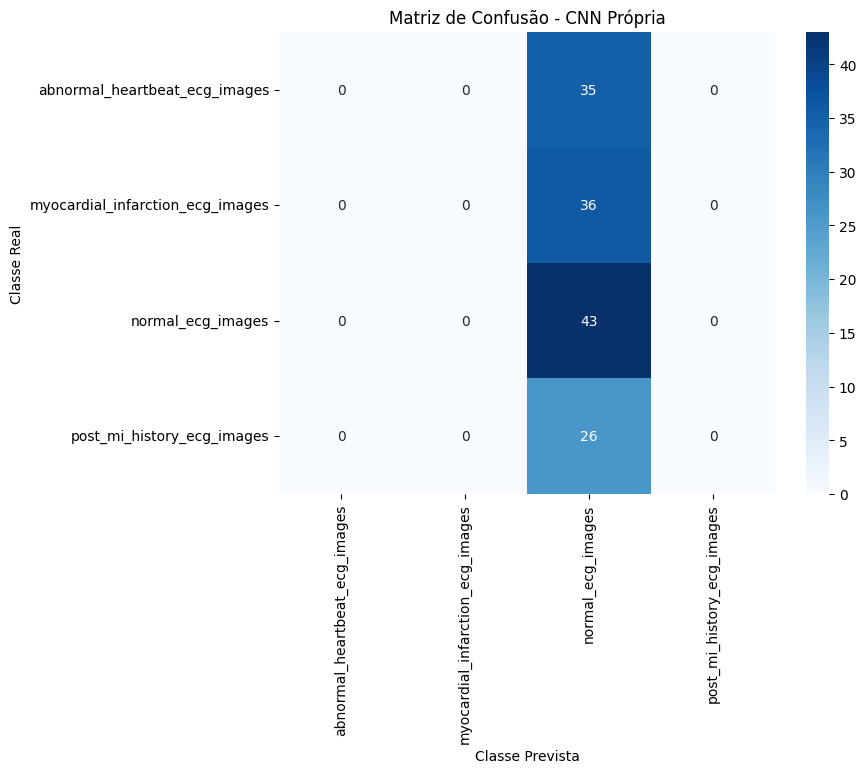

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred_probs = modelo.predict(test_generator)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(f"\nRELATÓRIO - {nome_modelo}\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Matriz de Confusão - {nome_modelo}")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

### Análise dos resultados da CNN desenvolvida do zero

Os resultados obtidos pela CNN construída do zero demonstraram limitações significativas na capacidade de classificação das imagens de eletrocardiograma.

O relatório de classificação apresentou acurácia global de aproximadamente 31%, valor próximo ao que seria esperado em um cenário de classificação aleatória entre quatro classes (25%). Além disso, observou-se que apenas a classe `normal_ecg_images` foi efetivamente reconhecida pelo modelo.

A matriz de confusão evidencia esse comportamento de forma clara. Todas as imagens do conjunto de teste foram classificadas como pertencentes à classe `normal_ecg_images`, independentemente de sua classe real. Como consequência, as classes:

- `abnormal_heartbeat_ecg_images`;
- `myocardial_infarction_ecg_images`;
- `post_mi_history_ecg_images`;

apresentaram precisão, recall e F1-score iguais a zero.

Por outro lado, a classe `normal_ecg_images` obteve recall igual a 1,00, indicando que todas as imagens dessa categoria foram corretamente identificadas. Entretanto, esse resultado não representa uma boa capacidade de classificação, pois o modelo simplesmente passou a prever a mesma classe para todas as amostras.

Esse comportamento sugere que a rede neural não conseguiu aprender características discriminantes suficientes para separar adequadamente as quatro categorias presentes no dataset.

Entre os possíveis fatores que contribuíram para esse resultado destacam-se:

- Quantidade limitada de imagens disponíveis para treinamento;
- Complexidade relativamente baixa da arquitetura proposta;
- Dificuldade da CNN em extrair características visuais mais sofisticadas a partir dos eletrocardiogramas;
- Similaridade visual entre algumas classes do dataset;
- Possível convergência para um mínimo local durante o treinamento.

Outro indicativo dessa limitação foi observado durante o treinamento, em que as métricas de acurácia permaneceram próximas de 30%, sem apresentar evolução significativa ao longo das épocas.

Como possíveis estratégias de melhoria, poderiam ser adotadas:

- Aumento da quantidade de imagens disponíveis para treinamento;
- Ampliação da profundidade da arquitetura convolucional;
- Ajuste de hiperparâmetros, como taxa de aprendizado, tamanho do batch e número de épocas;
- Utilização de técnicas adicionais de Data Augmentation;
- Aplicação de arquiteturas pré-treinadas por meio de Transfer Learning.

Os resultados obtidos nesta etapa justificam a utilização dos modelos ResNet50 e VGG16 nas fases seguintes do projeto. Essas arquiteturas já possuem conhecimento previamente adquirido em grandes bases de imagens e apresentam maior capacidade de extração de características visuais complexas, tornando-se alternativas mais adequadas para o problema de classificação dos eletrocardiogramas.

### 8.2 Análise do modelo ResNet50 com Fine Tuning

In [ ]:
modelo = resnet_model
nome_modelo = "ResNet50 Fine Tuning"

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step

RELATÓRIO - ResNet50 Fine Tuning

                                  precision    recall  f1-score   support

   abnormal_heartbeat_ecg_images       0.25      0.97      0.39        35
myocardial_infarction_ecg_images       0.00      0.00      0.00        36
               normal_ecg_images       1.00      0.02      0.05        43
      post_mi_history_ecg_images       0.00      0.00      0.00        26

                        accuracy                           0.25       140
                       macro avg       0.31      0.25      0.11       140
                    weighted avg       0.37      0.25      0.11       140



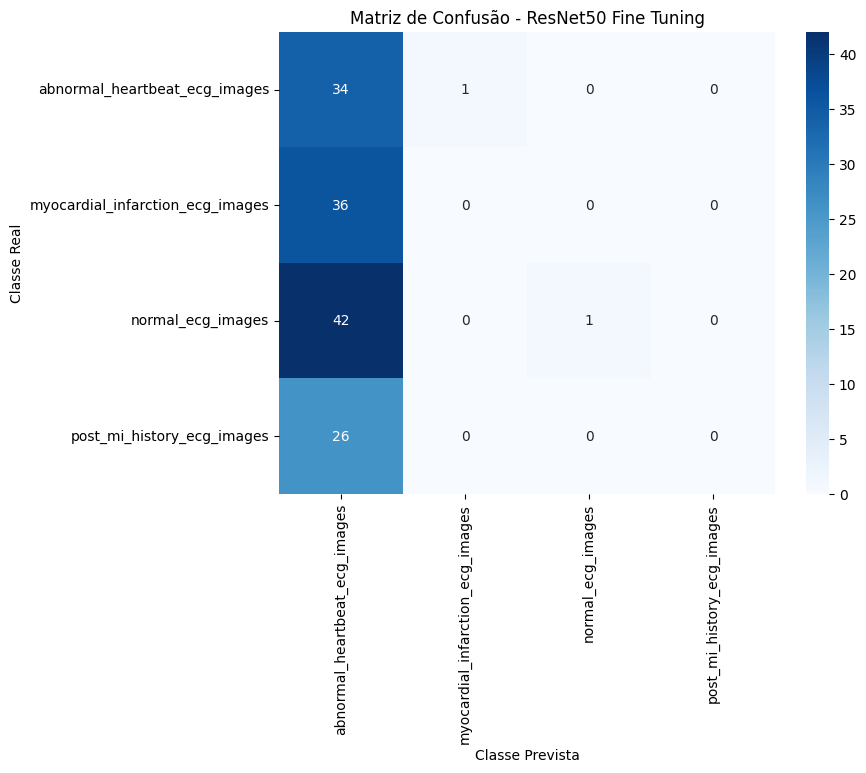

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred_probs = modelo.predict(test_generator)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(f"\nRELATÓRIO - {nome_modelo}\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Matriz de Confusão - {nome_modelo}")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

### Análise dos resultados da ResNet50 com Fine Tuning

Inicialmente foi avaliada a versão da ResNet50 utilizando apenas Transfer Learning, mantendo todas as camadas convolucionais congeladas. Posteriormente, foi aplicada a técnica de Fine Tuning, liberando parte das camadas finais da rede para treinamento.

Como o Fine Tuning apresentou maior capacidade de aprendizado durante o treinamento e permitiu adaptar melhor os pesos da rede às características específicas das imagens de eletrocardiograma, optou-se por utilizar essa versão nas análises detalhadas apresentadas nesta seção.

Os resultados obtidos demonstraram que o modelo passou a reconhecer parcialmente padrões relacionados à classe `abnormal_heartbeat_ecg_images`, alcançando recall de 97% para essa categoria.

A matriz de confusão evidencia que 34 das 35 imagens pertencentes à classe `abnormal_heartbeat_ecg_images` foram corretamente classificadas. Entretanto, o modelo apresentou dificuldades significativas para reconhecer as demais categorias do dataset.

As classes:

- `myocardial_infarction_ecg_images`;
- `normal_ecg_images`;
- `post_mi_history_ecg_images`;

foram classificadas predominantemente como `abnormal_heartbeat_ecg_images`, indicando forte viés do modelo para essa classe.

O relatório de classificação apresentou acurácia global de aproximadamente 25%, valor inferior ao observado durante o treinamento. Além disso, apenas uma imagem da classe `normal_ecg_images` foi corretamente identificada, enquanto nenhuma amostra das classes `myocardial_infarction_ecg_images` e `post_mi_history_ecg_images` foi reconhecida corretamente.

Esse comportamento sugere que o modelo sofreu overfitting durante o processo de Fine Tuning. Embora a acurácia de treinamento tenha atingido aproximadamente 54,94%, o desempenho no conjunto de teste permaneceu baixo, demonstrando dificuldade de generalização para dados não vistos.

Entre os possíveis fatores que contribuíram para esse resultado destacam-se:

- Quantidade limitada de imagens disponíveis para treinamento;
- Similaridade visual entre algumas categorias de eletrocardiogramas;
- Desbalanceamento ou baixa representatividade de determinados padrões clínicos;
- Excesso de adaptação das camadas liberadas durante o Fine Tuning aos exemplos de treinamento.

Observa-se ainda que o modelo passou a concentrar suas previsões em uma única categoria dominante, comportamento frequentemente associado a processos de treinamento que não conseguem estabelecer fronteiras de decisão adequadas entre todas as classes.

Como possíveis estratégias de melhoria poderiam ser avaliadas:

- Aumento do conjunto de treinamento;
- Ajuste da quantidade de camadas descongeladas durante o Fine Tuning;
- Utilização de técnicas de regularização adicionais;
- Aplicação de Early Stopping;
- Balanceamento das classes durante o treinamento;
- Ajuste da taxa de aprendizado utilizada na etapa de Fine Tuning.

Apesar das limitações observadas, a utilização do Fine Tuning permitiu compreender melhor o comportamento da ResNet50 no contexto deste projeto e serviu como importante etapa comparativa em relação à CNN desenvolvida do zero e à arquitetura VGG16.

### 8.3 Análise do modelo VGG16

In [ ]:
import numpy as np

# Previsões do modelo
pred_probs = vgg_model.predict(test_generator)

# Classe prevista
y_pred = np.argmax(pred_probs, axis=1)

# Classe real
y_true = test_generator.classes

# Nomes das classes
class_names = list(test_generator.class_indices.keys())

print(class_names)

5/5 ━━━━━━━━━━━━━━━━━━━━ 79s 15s/step
['abnormal_heartbeat_ecg_images', 'myocardial_infarction_ecg_images', 'normal_ecg_images', 'post_mi_history_ecg_images']


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                  precision    recall  f1-score   support

   abnormal_heartbeat_ecg_images       0.62      0.91      0.74        35
myocardial_infarction_ecg_images       0.40      0.92      0.56        36
               normal_ecg_images       0.50      0.07      0.12        43
      post_mi_history_ecg_images       0.00      0.00      0.00        26

                        accuracy                           0.49       140
                       macro avg       0.38      0.48      0.35       140
                    weighted avg       0.41      0.49      0.37       140



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


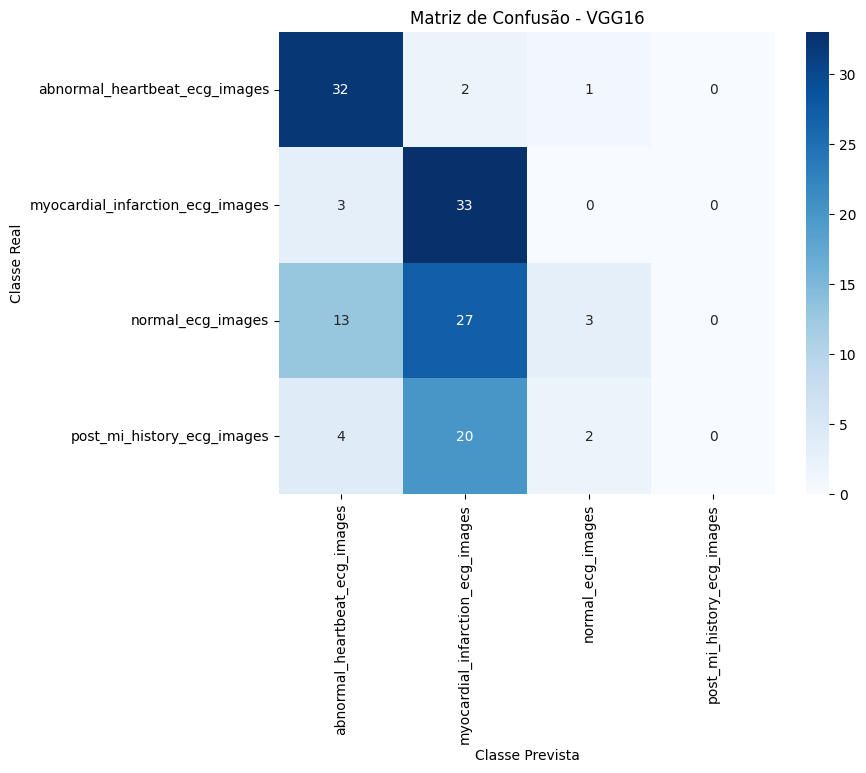

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - VGG16")

plt.show()

### Análise das curvas de treinamento

Por ter apresentado o melhor desempenho entre os modelos avaliados, o VGG16 foi selecionado para uma análise mais detalhada do comportamento de treinamento. Para isso, foram analisadas as curvas de acurácia e perda (loss) ao longo das épocas, permitindo avaliar a evolução do aprendizado e a capacidade de generalização da arquitetura.

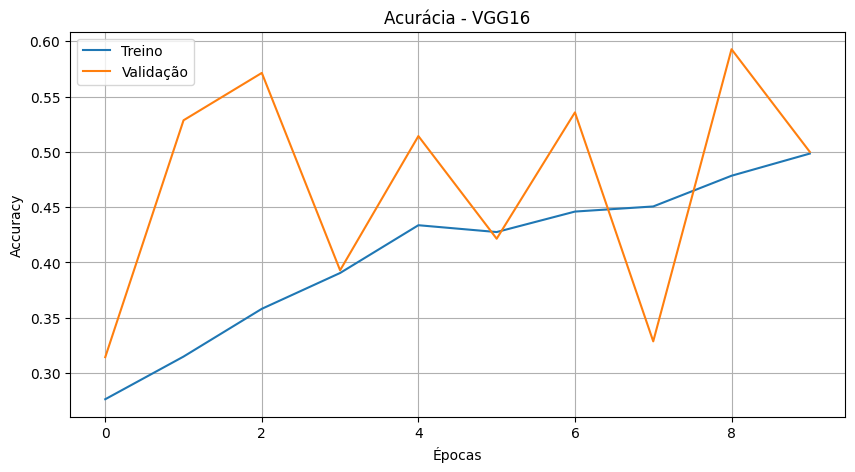

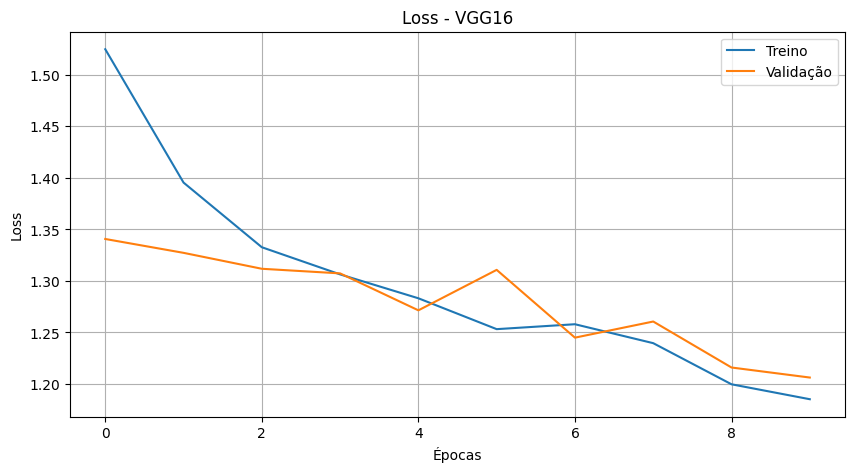

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history_vgg.history['accuracy'], label='Treino')
plt.plot(history_vgg.history['val_accuracy'], label='Validação')

plt.title('Acurácia - VGG16')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# Loss
plt.figure(figsize=(10,5))
plt.plot(history_vgg.history['loss'], label='Treino')
plt.plot(history_vgg.history['val_loss'], label='Validação')

plt.title('Loss - VGG16')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Análise do modelo VGG16

O modelo VGG16 apresentou o melhor desempenho entre as arquiteturas avaliadas neste projeto, superando tanto a CNN desenvolvida do zero quanto a ResNet50 com Fine Tuning.

A acurácia geral alcançada no conjunto de teste foi de aproximadamente 49%, representando o melhor resultado obtido entre os modelos analisados.

Ao observar o relatório de classificação, verifica-se que as classes `abnormal_heartbeat_ecg_images` e `myocardial_infarction_ecg_images` obtiveram os melhores resultados:

* abnormal_heartbeat_ecg_images:

  * Precisão: 62%
  * Recall: 91%
  * F1-Score: 74%

* myocardial_infarction_ecg_images:

  * Precisão: 40%
  * Recall: 92%
  * F1-Score: 56%

Esses resultados demonstram que o modelo conseguiu identificar adequadamente grande parte dos exames pertencentes às classes de anormalidade cardíaca e infarto do miocárdio.

A matriz de confusão confirma esse comportamento. Dos 35 exemplos da classe `abnormal_heartbeat_ecg_images`, 32 foram classificados corretamente. Já na classe `myocardial_infarction_ecg_images`, 33 dos 36 exames foram identificados corretamente, representando um dos melhores desempenhos observados durante o projeto.

O desempenho permaneceu mais limitado para as classes `normal_ecg_images` e `post_mi_history_ecg_images`.

Na classe `normal_ecg_images`, apenas 3 dos 43 exames foram classificados corretamente, enquanto a maior parte foi confundida principalmente com a classe `myocardial_infarction_ecg_images`.

Já a classe `post_mi_history_ecg_images` não apresentou classificações corretas, sendo frequentemente confundida com as classes de infarto e anormalidade cardíaca.

Esse comportamento sugere que o modelo conseguiu aprender padrões mais evidentes associados às alterações cardíacas e aos casos de infarto, porém apresentou dificuldade para distinguir situações clinicamente semelhantes, especialmente entre exames normais, histórico pós-infarto e demais alterações cardíacas.

A análise das curvas de treinamento e validação reforça essa conclusão. Observa-se crescimento gradual da acurácia de treinamento ao longo das épocas, partindo de aproximadamente 28% e alcançando cerca de 50% ao final do treinamento.

A acurácia de validação apresentou oscilações durante as épocas, comportamento esperado em bases relativamente pequenas, mas manteve tendência geral positiva, atingindo valores próximos de 59% em alguns momentos e encerrando o treinamento em aproximadamente 50%.

Diferentemente do observado na ResNet50 com Fine Tuning, não houve divergência significativa entre as curvas de treinamento e validação. Em diversos momentos ambas permaneceram próximas, indicando ausência de sinais evidentes de overfitting e sugerindo boa capacidade de generalização para dados não vistos.

A análise da função de perda (loss) confirma esse comportamento. Tanto a perda de treinamento quanto a perda de validação apresentaram redução consistente ao longo das épocas, convergindo para valores próximos de 1,20 ao final do treinamento. Essa convergência indica estabilidade no processo de aprendizagem e reforça a qualidade do ajuste obtido pelo modelo.

Outro aspecto importante é que o dataset utilizado possui quantidade relativamente limitada de imagens, o que reduz a capacidade do modelo de aprender representações robustas para todas as classes.

Além disso, algumas categorias podem compartilhar características visuais semelhantes nos eletrocardiogramas, aumentando a dificuldade de separação durante o processo de classificação.

Como possíveis estratégias de melhoria, podem ser consideradas:

* Ampliação do conjunto de dados;
* Aplicação de técnicas mais avançadas de Data Augmentation;
* Balanceamento das classes;
* Fine Tuning das camadas convolucionais da VGG16;
* Utilização de arquiteturas mais modernas, como EfficientNet ou DenseNet;
* Aplicação de validação cruzada para aumentar a robustez da avaliação.

Apesar das limitações observadas, o VGG16 foi o modelo que apresentou o melhor equilíbrio entre acertos, estabilidade durante o treinamento e capacidade de generalização, tornando-se a arquitetura de melhor desempenho dentre as soluções avaliadas neste projeto e sendo selecionado como modelo final do protótipo CardioIA Vision.

## 8.4 Comparação geral dos modelos

Após a avaliação individual das arquiteturas desenvolvidas, foi realizada uma comparação geral entre os modelos testados no projeto.

| Modelo                   | Acurácia no teste | Principais características observadas                                                                                                |
| ------------------------ | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| CNN Própria              | 31%               | Apresentou forte viés para uma única classe, demonstrando baixa capacidade de generalização.                                         |
| ResNet50 com Fine Tuning | 25%               | Obteve melhora durante o treinamento, porém apresentou baixa capacidade de generalização e desempenho limitado no conjunto de teste. |
| VGG16                    | 49%               | Apresentou o melhor equilíbrio entre aprendizado, generalização e capacidade de identificação das classes analisadas.                |

A CNN desenvolvida do zero apresentou limitações significativas para aprender padrões discriminativos entre as quatro categorias de ECG, concentrando a maior parte das previsões em uma única classe e demonstrando dificuldade para diferenciar os grupos avaliados.

A ResNet50, mesmo utilizando Transfer Learning e Fine Tuning, não conseguiu transferir adequadamente o conhecimento aprendido na ImageNet para o contexto específico dos eletrocardiogramas. Embora tenha apresentado evolução durante o treinamento, seu desempenho final permaneceu inferior ao esperado, indicando dificuldades de adaptação ao conjunto de dados utilizado.

O modelo VGG16 foi o que apresentou os melhores resultados gerais, alcançando aproximadamente 49% de acurácia no conjunto de teste. Além disso, obteve excelente capacidade de identificação das classes relacionadas a anormalidades cardíacas e infarto do miocárdio, atingindo recalls superiores a 90% nessas categorias.

As curvas de treinamento e validação também demonstraram comportamento mais estável quando comparadas às demais arquiteturas, apresentando redução consistente da função de perda e ausência de sinais evidentes de overfitting.

Dessa forma, considerando as métricas de classificação, a matriz de confusão, as curvas de treinamento e a capacidade de generalização observada, o VGG16 foi selecionado como a arquitetura de melhor desempenho para representar o protótipo CardioIA Vision nesta fase do projeto.


## 8.5 Seleção do modelo final

Com base nos resultados obtidos durante os experimentos, o modelo VGG16 foi selecionado como a solução final desta etapa do projeto.

A escolha foi realizada considerando não apenas a acurácia global, mas também a capacidade de generalização observada durante o treinamento, os resultados do relatório de classificação e o comportamento apresentado nas matrizes de confusão.

Embora nenhum dos modelos tenha alcançado níveis de desempenho compatíveis com aplicações clínicas reais, o VGG16 apresentou resultados superiores aos demais modelos avaliados, demonstrando maior capacidade de identificar corretamente padrões associados a anormalidades cardíacas e infarto do miocárdio.

Além disso, as curvas de treinamento indicaram comportamento mais estável e menor evidência de overfitting quando comparado à ResNet50 com Fine Tuning.

Por esses motivos, o VGG16 foi adotado como modelo final do protótipo CardioIA Vision para esta fase do projeto.


## 8.6 Aplicação no contexto CardioIA

O CardioIA Vision foi desenvolvido como um módulo de Visão Computacional capaz de auxiliar a análise de eletrocardiogramas por meio da classificação automática de imagens médicas.

No contexto do ecossistema CardioIA, o modelo selecionado poderá atuar como uma camada inicial de triagem inteligente, identificando padrões visuais associados a diferentes condições cardíacas e fornecendo informações de apoio para profissionais da saúde.

É importante destacar que o sistema não tem como objetivo substituir o diagnóstico médico, mas sim atuar como ferramenta complementar de apoio à decisão clínica.

Em futuras evoluções do projeto, o modelo poderá ser integrado aos demais módulos desenvolvidos nas fases anteriores, permitindo a construção de uma plataforma mais completa para monitoramento, análise e suporte ao diagnóstico cardiovascular.

Dessa forma, esta fase demonstra de maneira prática como técnicas de Visão Computacional e Inteligência Artificial podem contribuir para a interpretação automatizada de exames médicos, alinhando-se aos objetivos propostos pelo projeto CardioIA.


# 9. Conclusão

Este projeto teve como objetivo investigar a aplicação de técnicas de Visão Computacional e Deep Learning na classificação automática de eletrocardiogramas (ECG), utilizando imagens pertencentes a quatro categorias distintas: batimentos cardíacos anormais, infarto do miocárdio, exames normais e histórico pós-infarto.

Inicialmente, foi desenvolvida uma Rede Neural Convolucional (CNN) própria, construída do zero, com o objetivo de estabelecer uma linha de base para comparação. Em seguida, foram avaliadas arquiteturas amplamente utilizadas na literatura por meio da estratégia de Transfer Learning, utilizando os modelos ResNet50 e VGG16 pré-treinados na base ImageNet.

Durante o desenvolvimento do projeto foram realizadas as etapas de inspeção do dataset, pré-processamento das imagens, normalização, redimensionamento, divisão em conjuntos de treinamento, validação e teste, além da aplicação de técnicas de Data Augmentation para aumentar a capacidade de generalização dos modelos.

Os resultados demonstraram que a CNN própria apresentou desempenho limitado, concentrando suas previsões em uma única classe e evidenciando dificuldade para aprender representações discriminativas adequadas do conjunto de dados. A ResNet50, mesmo após a aplicação de Fine Tuning, apresentou evolução durante o treinamento, porém manteve baixa capacidade de generalização, resultando em desempenho inferior ao esperado no conjunto de teste.

Entre os modelos avaliados, o VGG16 apresentou os melhores resultados gerais, alcançando aproximadamente 49% de acurácia no conjunto de teste e demonstrando elevada capacidade de identificação das classes relacionadas a anormalidades cardíacas e infarto do miocárdio. A análise das curvas de treinamento indicou comportamento estável, com redução consistente da função de perda e ausência de sinais evidentes de overfitting. A matriz de confusão confirmou que o modelo foi capaz de identificar corretamente a maior parte dos exames dessas categorias, embora ainda tenha apresentado dificuldades na diferenciação das classes normal e histórico pós-infarto.

Além do desenvolvimento e avaliação dos modelos, foi criado um protótipo interativo capaz de receber imagens de eletrocardiogramas e apresentar automaticamente a classificação prevista pelo modelo selecionado. Esse protótipo demonstra, de forma prática, como técnicas de Inteligência Artificial podem ser incorporadas a sistemas de apoio à decisão clínica.

Os resultados obtidos demonstram que a utilização de arquiteturas pré-treinadas constitui uma alternativa promissora para problemas de classificação de imagens médicas, especialmente em cenários onde a quantidade de dados disponíveis é limitada. Ao mesmo tempo, evidenciam os desafios inerentes à análise de eletrocardiogramas, cujas classes frequentemente apresentam características visuais semelhantes.

Como trabalhos futuros, recomenda-se a ampliação do conjunto de dados, a aplicação de técnicas mais avançadas de Data Augmentation, o balanceamento das classes, a realização de Fine Tuning mais aprofundado nas camadas convolucionais da VGG16 e a avaliação de arquiteturas mais modernas, como EfficientNet, DenseNet e Vision Transformers. Também podem ser exploradas abordagens híbridas que combinem análise de imagens e processamento de sinais cardíacos para aumentar a capacidade de discriminação dos modelos.

Dessa forma, conclui-se que os objetivos propostos para a Fase 4 foram alcançados. O projeto permitiu construir, treinar, comparar e avaliar diferentes arquiteturas de Deep Learning aplicadas à classificação de eletrocardiogramas, além de disponibilizar um protótipo funcional para demonstração dos resultados. O estudo também contribuiu para a compreensão dos benefícios, limitações e desafios envolvidos na aplicação da Inteligência Artificial ao contexto da saúde, reforçando o potencial dessas tecnologias como ferramentas de apoio ao diagnóstico médico.


# PROTÓTIPO UTILIZANDO VGG16

O protótipo CardioIA Vision foi desenvolvido para demonstrar, de forma prática, a aplicação do modelo VGG16 treinado ao longo deste projeto.

A interface permite que o usuário informe o nome do paciente, realize o upload de uma imagem de eletrocardiograma e receba automaticamente a classificação prevista pelo modelo de Inteligência Artificial.

O objetivo não é substituir a avaliação médica, mas sim demonstrar como técnicas de Visão Computacional podem ser utilizadas como ferramenta de apoio à tomada de decisão clínica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

modelo = load_model("/content/drive/MyDrive/CardioIA_Vision/vgg16_cardioia_model.keras")

classes = [
    "Batimento Cardíaco Anormal",
    "Infarto do Miocárdio",
    "ECG Normal",
    "Histórico Pós-Infarto"
]

nome_input = widgets.Text(
    placeholder="Digite o nome do paciente",
    description="Paciente:",
    layout=widgets.Layout(width="60%")
)

upload = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False,
    description="Enviar ECG"
)

botao = widgets.Button(
    description="Analisar ECG",
    button_style="primary"
)

saida = widgets.Output()

def analisar_ecg(b):
    with saida:
        clear_output()

        if not nome_input.value:
            print("Informe o nome do paciente.")
            return

        if len(upload.value) == 0:
            print("Envie uma imagem de ECG.")
            return

        arquivo_info = list(upload.value.values())[0]
        imagem_bytes = arquivo_info["content"]

        img = Image.open(io.BytesIO(imagem_bytes)).convert("RGB")
        img_redimensionada = img.resize((224, 224))

        img_array = np.array(img_redimensionada) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = modelo.predict(img_array)
        classe_idx = np.argmax(pred)
        classe_prevista = classes[classe_idx]
        confianca = np.max(pred) * 100

        plt.figure(figsize=(7, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Imagem enviada para análise")
        plt.show()

        print("=" * 50)
        print("CARDIOIA VISION")
        print("Assistente Cardiológico Virtual")
        print("=" * 50)
        print(f"Paciente: {nome_input.value}")
        print(f"Classe prevista: {classe_prevista}")
        print(f"Confiança: {confianca:.2f}%")
        print("\nObservação:")
        print("Este protótipo demonstra a aplicação do modelo desenvolvido.")
        print("O resultado exibido não representa validação da acurácia do modelo.")
        print("A avaliação de desempenho foi realizada separadamente pelas métricas do trabalho.")
        print("Este sistema possui finalidade acadêmica e não substitui avaliação médica profissional.")

botao.on_click(analisar_ecg)

display(widgets.HTML("<h2>CardioIA Vision - Protótipo Interativo</h2>"))
display(widgets.HTML("<p>Informe o paciente, envie uma imagem de ECG e execute a análise pelo modelo VGG16.</p>"))
display(nome_input)
display(upload)
display(botao)
display(saida)

HTML(value='<h2>CardioIA Vision - Protótipo Interativo</h2>')

HTML(value='<p>Informe o paciente, envie uma imagem de ECG e execute a análise pelo modelo VGG16.</p>')

Text(value='', description='Paciente:', layout=Layout(width='60%'), placeholder='Digite o nome do paciente')

FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Enviar ECG')

Button(button_style='primary', description='Analisar ECG', style=ButtonStyle())

Output()